In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['FarePerPerson'] = df['Fare'] / df['FamilySize']
df = df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data ready. Shape:", X.shape)

Data ready. Shape: (891, 11)


In [3]:
xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',    # suppresses a warning
    verbosity=0               # suppresses extra output
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 4))
print("XGBoost F1 Score:", round(f1_score(y_test, y_pred_xgb), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8045
XGBoost F1 Score: 0.7328

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       110
           1       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [5]:
rf_model = RandomForestClassifier(
    random_state=42,
    max_depth=6,
    min_samples_leaf=4,
    n_estimators=200
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Side by side comparison
print(f"{'Model':<20} {'Accuracy':<12} {'F1 Score'}")
print("-" * 45)
print(f"{'Random Forest':<20} {accuracy_score(y_test, y_pred_rf):<12.4f} {f1_score(y_test, y_pred_rf):.4f}")
print(f"{'XGBoost':<20} {accuracy_score(y_test, y_pred_xgb):<12.4f} {f1_score(y_test, y_pred_xgb):.4f}")


Model                Accuracy     F1 Score
---------------------------------------------
Random Forest        0.8045       0.7244
XGBoost              0.8045       0.7328


In [8]:
# Tuned XGBoost
xgb_tuned = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,   #Try changing lr
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb_tuned, X, y, cv=cv, scoring='accuracy')

print("Tuned XGBoost CV scores:", scores.round(4))
print(f"Mean accuracy: {scores.mean():.4f}")
print(f"Std deviation: {scores.std():.4f}")

Tuned XGBoost CV scores: [0.8659 0.8483 0.809  0.8202 0.8539]
Mean accuracy: 0.8395
Std deviation: 0.0214


In [9]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

xgb_early = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    n_estimators=1000,       
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50 # stop if no improvement for 50 rounds
)

xgb_early.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Best iteration: {xgb_early.best_iteration}")
print(f"Best validation score: {xgb_early.best_score:.4f}")

# Evaluate on test set
y_pred_early = xgb_early.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_early):.4f}")
print(f"Test F1 Score: {f1_score(y_test, y_pred_early):.4f}")

Best iteration: 115
Best validation score: 0.3966
Test Accuracy: 0.7933
Test F1 Score: 0.7132


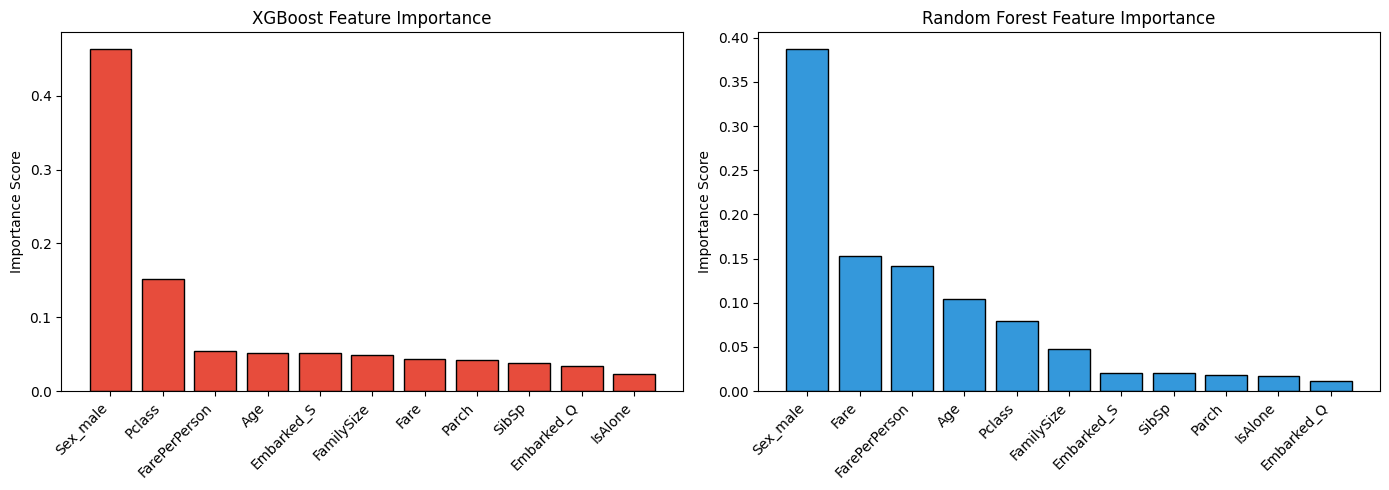

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xgb_tuned.fit(X_train, y_train)
xgb_importance = xgb_tuned.feature_importances_
indices = np.argsort(xgb_importance)[::-1]
feature_names = X.columns

axes[0].bar(range(len(xgb_importance)),
            xgb_importance[indices],
            color='#e74c3c', edgecolor='black')
axes[0].set_xticks(range(len(xgb_importance)))
axes[0].set_xticklabels(feature_names[indices], rotation=45, ha='right')
axes[0].set_title('XGBoost Feature Importance')
axes[0].set_ylabel('Importance Score')

# Random Forest importance
rf_model.fit(X_train, y_train)
rf_importance = rf_model.feature_importances_
indices_rf = np.argsort(rf_importance)[::-1]

axes[1].bar(range(len(rf_importance)),
            rf_importance[indices_rf],
            color='#3498db', edgecolor='black')
axes[1].set_xticks(range(len(rf_importance)))
axes[1].set_xticklabels(feature_names[indices_rf], rotation=45, ha='right')
axes[1].set_title('Random Forest Feature Importance')
axes[1].set_ylabel('Importance Score')

plt.tight_layout()
plt.show()

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb_tuned, X, y, cv=cv, scoring='accuracy')
print(f"Mean accuracy: {scores.mean():.4f}")
print(f"Std deviation: {scores.std():.4f}")

Mean accuracy: 0.8395
Std deviation: 0.0214
